In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import os
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from _utils._utils_spline import eval_spline_basis_equispaced_numeric

In [2]:
okabe_ito_colors = np.array(["#000000", "#E69F00", "#56B4E9", "#009E73", "#F0E442",
          "#0072B2","#D55E00", "#CC79A7", "#999999"])

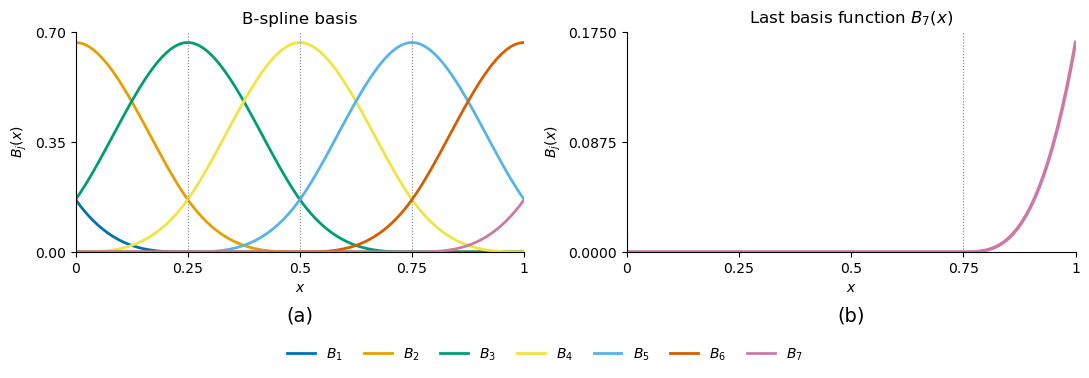

In [3]:
degree = 3
x_plot = np.linspace(0, 1, 100)
num_knots = 3

B_plot_dict = eval_spline_basis_equispaced_numeric(
    degree, 0, 1, num_knots, x_plot
)

B_plot = B_plot_dict["B"]
interior_knots = B_plot_dict["interior_knots"]

n, k = B_plot.shape

# Okabe–Ito colour-blind-friendly palette
colors = okabe_ito_colors[[5, 1, 3, 4, 2, 6, 7]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ============================================================
# Left: full B-spline basis
# ============================================================
ax = axes[0]

for j in range(k):
    ax.plot(
        x_plot,
        B_plot[:, j],
        color=colors[j],
        lw=2,
        label=fr"$B_{{{j+1}}}$"
    )

for knot in interior_knots:
    ax.axvline(
        knot,
        color="0.5",
        lw=0.8,
        ls=":"
    )

# Scale independently so the maximum reaches the top
left_max = B_plot.max()
ax.set_ylim(0, left_max*1.05)
ax.set_xlim(0, 1)

ax.set_title("B-spline basis")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$B_j(x)$")

# ============================================================
# Right: last basis function
# ============================================================
ax = axes[1]

last_color = colors[-1]

ax.plot(
    x_plot,
    B_plot[:, -1],
    color=last_color,
    lw=2.5,
    label=fr"$B_{{{k}}}$"
)

# Penultimate interior knot
ax.axvline(
    interior_knots[-1],
    color="0.5",
    lw=0.8,
    ls=":"
)

# Independent scale
right_max = B_plot[:, -1].max()
ax.set_ylim(0, right_max*1.05)
ax.set_xlim(0, 1)

ax.set_title(fr"Last basis function $B_{{{k}}}(x)$")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$B_j(x)$")

# ============================================================
# Common formatting
# ============================================================

xticks = np.r_[0, interior_knots, 1]
xticks = np.unique(xticks)

for ax in axes:
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{x:g}" for x in xticks])

    # Few y-axis labels
    ax.set_yticks(np.linspace(0, ax.get_ylim()[1], 3))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ============================================================
# Panel labels
# ============================================================

label_dip = -0.25
label_fontsize = 14
axes[0].text(
    0.5, label_dip, "(a)",
    transform=axes[0].transAxes,
    ha="center",
    va="top",
    fontsize=label_fontsize
)

axes[1].text(
    0.5, label_dip, "(b)",
    transform=axes[1].transAxes,
    ha="center",
    va="top",
    fontsize=label_fontsize
)

# ============================================================
# One combined legend, centred underneath both plots
# ============================================================

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.05),
    ncol=k,
    frameon=False,
    columnspacing=1.5
)

# Leave room for the legend
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("figure_basis.pdf", bbox_inches="tight", dpi=300)
plt.show()

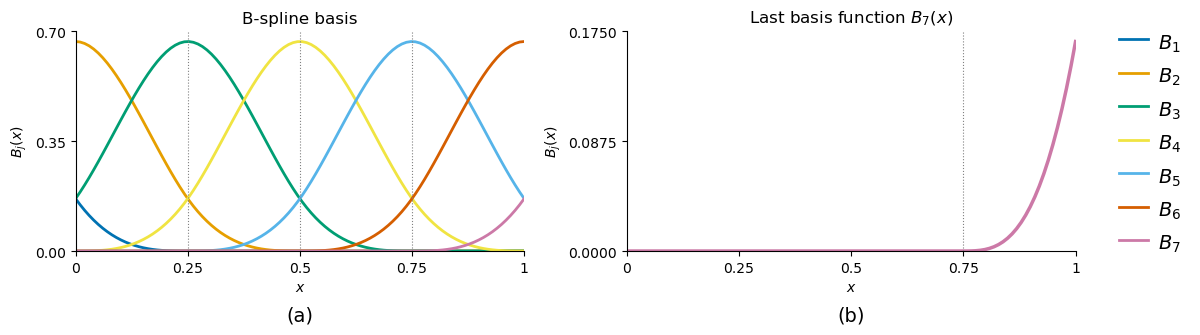

In [4]:
degree = 3
x_plot = np.linspace(0, 1, 100)
num_knots = 3

B_plot_dict = eval_spline_basis_equispaced_numeric(
    degree, 0, 1, num_knots, x_plot
)

B_plot = B_plot_dict["B"]
interior_knots = B_plot_dict["interior_knots"]

n, k = B_plot.shape

# Okabe–Ito colour-blind-friendly palette
colors = okabe_ito_colors[[5, 1, 3, 4, 2, 6, 7]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ============================================================
# Left: full B-spline basis
# ============================================================
ax = axes[0]

for j in range(k):
    ax.plot(
        x_plot,
        B_plot[:, j],
        color=colors[j],
        lw=2,
        label=fr"$B_{{{j+1}}}$"
    )

for knot in interior_knots:
    ax.axvline(
        knot,
        color="0.5",
        lw=0.8,
        ls=":"
    )

# Scale independently so the maximum reaches the top
left_max = B_plot.max()
ax.set_ylim(0, left_max*1.05)
ax.set_xlim(0, 1)

ax.set_title("B-spline basis")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$B_j(x)$")

# ============================================================
# Right: last basis function
# ============================================================
ax = axes[1]

last_color = colors[-1]

ax.plot(
    x_plot,
    B_plot[:, -1],
    color=last_color,
    lw=2.5,
    label=fr"$B_{{{k}}}$"
)

# Penultimate interior knot
ax.axvline(
    interior_knots[-1],
    color="0.5",
    lw=0.8,
    ls=":"
)

# Independent scale
right_max = B_plot[:, -1].max()
ax.set_ylim(0, right_max*1.05)
ax.set_xlim(0, 1)

ax.set_title(fr"Last basis function $B_{{{k}}}(x)$")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$B_j(x)$")

# ============================================================
# Common formatting
# ============================================================

xticks = np.r_[0, interior_knots, 1]
xticks = np.unique(xticks)

for ax in axes:
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{x:g}" for x in xticks])

    # Few y-axis labels
    ax.set_yticks(np.linspace(0, ax.get_ylim()[1], 3))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ============================================================
# Panel labels
# ============================================================

label_dip = -0.25
label_fontsize = 14
axes[0].text(
    0.5, label_dip, "(a)",
    transform=axes[0].transAxes,
    ha="center",
    va="top",
    fontsize=label_fontsize
)

axes[1].text(
    0.5, label_dip, "(b)",
    transform=axes[1].transAxes,
    ha="center",
    va="top",
    fontsize=label_fontsize
)

# ============================================================
# One combined legend, centred underneath both plots
# ============================================================

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(1.05, 0.3),
    ncol=1,
    frameon=False,
    columnspacing=1.0,
    fontsize=14,
    handlelength=1.5,
    handleheight=1.5,
    handletextpad=0.5,
    labelspacing=0.5,
    borderpad=0.5
)

# Leave room for the legend
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("figure_basis.pdf", bbox_inches="tight", dpi=300)
plt.show()